# Vinculación SPI — Random Forest
## Tabla de afectación productiva por nivel de sequía · Caldas

Este notebook construye la tabla que le presenta al caficultor la relación histórica entre:
- Nivel de sequía (SPI-9)
- Afectación típica de la producción
- Porcentaje de pago simulado del seguro

**Inputs requeridos:**
- `modelo_rf_m4.pkl` — modelo Random Forest M4 entrenado
- `cafe_seguro_master.csv` — dataset maestro con producción histórica y variables climáticas
- `resultado_spi_multiescala_pago.csv` — SPI-9, SPI-6 y pagos simulados por mes

## Sección A — Imports y carga de archivos

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# --- A.1 Cargar modelo Random Forest M4 ---
modelo_rf = joblib.load('modelo_rf_m4.pkl')
print('Modelo cargado:', type(modelo_rf))

# --- A.2 Cargar dataset maestro ---
df_master = pd.read_csv('cafe_seguro_master.csv', parse_dates=['fecha'])
df_master = df_master.sort_values('fecha').reset_index(drop=True)
print(f'\nDataset maestro: {df_master.shape}')
print(f'Periodo: {df_master["fecha"].min().date()} → {df_master["fecha"].max().date()}')
print(df_master.head(3))

# --- A.3 Cargar dataset SPI con pagos simulados ---
df_spi = pd.read_csv('resultado_spi_multiescala_pago.csv', parse_dates=['fecha'])
df_spi = df_spi[df_spi['departamento'] == 'Caldas'].copy()
df_spi = df_spi.sort_values('fecha').reset_index(drop=True)
print(f'\nDataset SPI Caldas: {df_spi.shape}')
print(f'Periodo: {df_spi["fecha"].min().date()} → {df_spi["fecha"].max().date()}')
print(df_spi[['fecha', 'spi_6', 'spi_9', 'pago_spi_6', 'pago_spi_9']].head(3))

Modelo cargado: <class 'sklearn.ensemble._forest.RandomForestRegressor'>

Dataset maestro: (288, 10)
Periodo: 2002-01-01 → 2025-12-01
       fecha  year  month  prod_caldas_miles_sacos  prod_nacional_miles_sacos  \
0 2002-01-01  2002      1                84.600091                      824.0   
1 2002-02-01  2002      2                82.957371                      808.0   
2 2002-03-01  2002      3                79.877271                      778.0   

   precip_mm  ndvi_mean  ndvi_median  ndvi_p90  precio_interno_cop  
0  118.09220   0.803733     0.822325  0.888642            276480.0  
1  135.23131   0.745381     0.779234  0.865231            270960.0  
2  234.06622   0.684195     0.732444  0.845712            296859.0  

Dataset SPI Caldas: (542, 42)
Periodo: 1981-01-01 → 2026-02-01
       fecha  spi_6  spi_9  pago_spi_6  pago_spi_9
0 1981-01-01    NaN    NaN         NaN         NaN
1 1981-02-01    NaN    NaN         NaN         NaN
2 1981-03-01    NaN    NaN         NaN         N

## Sección B — Feature engineering para estimación con Random Forest

In [45]:
# --- B.1 Construir las mismas 15 features que usó el modelo M4 ---
# Es crítico que estas features sean exactamente iguales a las del notebook de entrenamiento

TARGET = 'prod_caldas_miles_sacos'

df_feat = df_master.copy()

# Rezagos de producción propia
for lag in [1, 2, 3, 6, 12]:
    df_feat[f'prod_lag{lag}'] = df_feat[TARGET].shift(lag)

# Rezagos de precipitación
for lag in [1, 3, 6, 10]:
    df_feat[f'precip_lag{lag}'] = df_feat['precip_mm'].shift(lag)

# Rezagos de NDVI
for lag in [1, 3, 5]:
    df_feat[f'ndvi_lag{lag}'] = df_feat['ndvi_mean'].shift(lag)

# Estacionalidad cíclica
df_feat['mes_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['mes_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)

# Tendencia lineal
df_feat['tendencia'] = np.arange(len(df_feat))

# Eliminar filas con NaN generados por los rezagos
df_feat = df_feat.dropna().reset_index(drop=True)

FEATURE_COLS = [
    'prod_lag1', 'prod_lag2', 'prod_lag3', 'prod_lag6', 'prod_lag12',
    'precip_lag1', 'precip_lag3', 'precip_lag6', 'precip_lag10',
    'ndvi_lag1', 'ndvi_lag3', 'ndvi_lag5',
    'mes_sin', 'mes_cos', 'tendencia'
]

print(f'Registros disponibles tras eliminar NaN: {len(df_feat)}')
print(f'Periodo efectivo: {df_feat["fecha"].min().date()} → {df_feat["fecha"].max().date()}')
print(f'Features: {FEATURE_COLS}')

Registros disponibles tras eliminar NaN: 276
Periodo efectivo: 2003-01-01 → 2025-12-01
Features: ['prod_lag1', 'prod_lag2', 'prod_lag3', 'prod_lag6', 'prod_lag12', 'precip_lag1', 'precip_lag3', 'precip_lag6', 'precip_lag10', 'ndvi_lag1', 'ndvi_lag3', 'ndvi_lag5', 'mes_sin', 'mes_cos', 'tendencia']


## Sección C — Estimación de producción con Random Forest M4

In [48]:
# --- C.1 Estimar producción para toda la serie histórica ---
X_completo = df_feat[FEATURE_COLS]
df_feat['prod_estimada_rf'] = modelo_rf.predict(X_completo)

print('=== PRODUCCIÓN ESTIMADA ===')
print(df_feat[['fecha', TARGET, 'prod_estimada_rf']].head(10).round(2))

print(f'\nEstadísticas producción observada vs estimada:')
print(pd.DataFrame({
    'Observada': df_feat[TARGET].describe(),
    'Estimada RF': df_feat['prod_estimada_rf'].describe()
}).round(2))

=== PRODUCCIÓN ESTIMADA ===
       fecha  prod_caldas_miles_sacos  prod_estimada_rf
0 2003-01-01                    93.91             98.26
1 2003-02-01                    80.09             84.40
2 2003-03-01                    65.45             71.39
3 2003-04-01                   109.56            101.18
4 2003-05-01                    98.79            105.32
5 2003-06-01                   109.46            108.13
6 2003-07-01                   108.95            102.78
7 2003-08-01                    67.18             79.17
8 2003-09-01                    80.80             79.79
9 2003-10-01                   115.56            105.84

Estadísticas producción observada vs estimada:
       Observada  Estimada RF
count     276.00       276.00
mean       81.45        81.85
std        21.68        17.73
min        32.60        45.55
25%        66.29        69.64
50%        79.59        81.73
75%        95.53        92.71
max       152.11       129.66


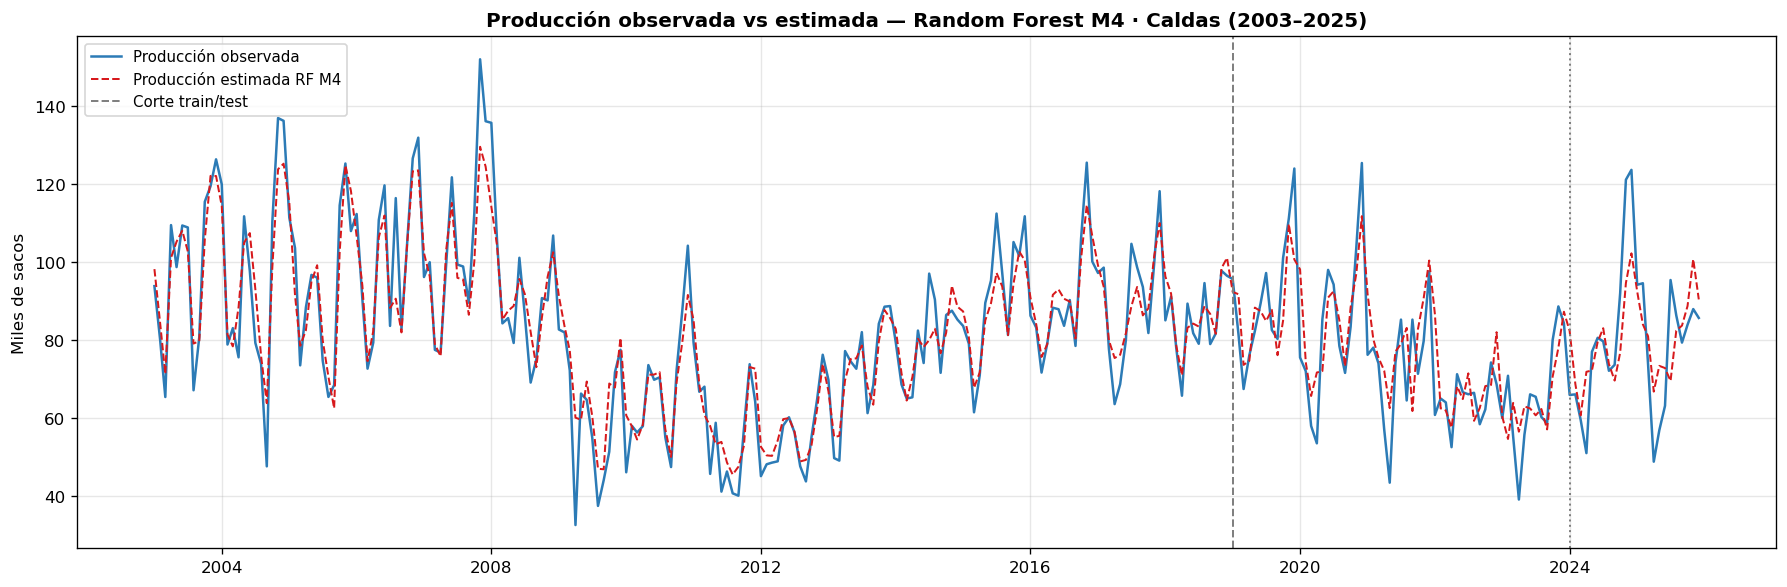

Gráfica guardada: vinc_C_produccion_obs_vs_estimada.png


In [50]:
# --- C.2 Visualización: producción observada vs estimada ---
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df_feat['fecha'], df_feat[TARGET],
        color='#2c7bb6', lw=1.5, label='Producción observada')
ax.plot(df_feat['fecha'], df_feat['prod_estimada_rf'],
        color='#d7191c', lw=1.2, linestyle='--', label='Producción estimada RF M4')

ax.axvline(pd.Timestamp('2019-01-01'), color='gray', lw=1.2,
           linestyle='--', label='Corte train/test')
ax.axvline(pd.Timestamp('2024-01-01'), color='gray', lw=1.2, linestyle=':')

ax.set_ylabel('Miles de sacos')
ax.set_title('Producción observada vs estimada — Random Forest M4 · Caldas (2003–2025)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('vinc_C_produccion_obs_vs_estimada.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: vinc_C_produccion_obs_vs_estimada.png')

## Sección D — Cruce con SPI y pagos simulados

In [53]:
# --- D.1 Seleccionar columnas relevantes del dataset SPI ---
df_spi_sel = df_spi[['fecha', 'spi_6', 'spi_9', 'pago_spi_6', 'pago_spi_9']].copy()

# --- D.2 Cruzar dataset maestro con SPI por fecha ---
df_vinc = df_feat[['fecha', 'month', TARGET, 'prod_estimada_rf']].merge(
    df_spi_sel, on='fecha', how='inner'
)

print(f'=== DATASET VINCULADO ===')
print(f'Registros: {len(df_vinc)}')
print(f'Periodo: {df_vinc["fecha"].min().date()} → {df_vinc["fecha"].max().date()}')
print(f'Valores nulos:\n{df_vinc.isnull().sum()}')
print(df_vinc.head(5).round(3))

=== DATASET VINCULADO ===
Registros: 276
Periodo: 2003-01-01 → 2025-12-01
Valores nulos:
fecha                      0
month                      0
prod_caldas_miles_sacos    0
prod_estimada_rf           0
spi_6                      0
spi_9                      0
pago_spi_6                 0
pago_spi_9                 0
dtype: int64
       fecha  month  prod_caldas_miles_sacos  prod_estimada_rf  spi_6  spi_9  \
0 2003-01-01      1                   93.911            98.264 -1.421 -1.317   
1 2003-02-01      2                   80.089            84.396 -1.243 -1.251   
2 2003-03-01      3                   65.453            71.389 -1.225 -1.240   
3 2003-04-01      4                  109.563           101.183 -0.963 -1.193   
4 2003-05-01      5                   98.789           105.319 -0.738 -1.225   

   pago_spi_6  pago_spi_9  
0       0.421       0.317  
1       0.243       0.251  
2       0.225       0.240  
3       0.000       0.193  
4       0.000       0.225  


## Sección E — Variación de producción respecto al promedio histórico del mes

In [56]:
# --- E.1 Calcular promedio histórico de producción por mes calendario ---
# Se usa solo el periodo de entrenamiento (hasta 2018) como referencia histórica
# para evitar que el test contamine el promedio de referencia

promedio_mes = (
    df_vinc[df_vinc['fecha'] <= '2018-12-01']
    .groupby('month')[TARGET]
    .mean()
    .rename('prod_promedio_historico')
)

df_vinc = df_vinc.merge(promedio_mes, on='month', how='left')

# --- E.2 Calcular variación de producción observada vs promedio histórico ---
df_vinc['variacion_obs_pct'] = (
    (df_vinc[TARGET] - df_vinc['prod_promedio_historico'])
    / df_vinc['prod_promedio_historico'] * 100
).round(1)

# --- E.3 Calcular variación de producción estimada vs promedio histórico ---
df_vinc['variacion_est_pct'] = (
    (df_vinc['prod_estimada_rf'] - df_vinc['prod_promedio_historico'])
    / df_vinc['prod_promedio_historico'] * 100
).round(1)

print('=== VARIACIONES DE PRODUCCIÓN ===')
print(df_vinc[['fecha', TARGET, 'prod_promedio_historico',
               'variacion_obs_pct', 'variacion_est_pct']].head(10).round(2))

=== VARIACIONES DE PRODUCCIÓN ===
       fecha  prod_caldas_miles_sacos  prod_promedio_historico  \
0 2003-01-01                    93.91                    89.06   
1 2003-02-01                    80.09                    80.28   
2 2003-03-01                    65.45                    69.09   
3 2003-04-01                   109.56                    70.20   
4 2003-05-01                    98.79                    84.19   
5 2003-06-01                   109.46                    85.89   
6 2003-07-01                   108.95                    82.49   
7 2003-08-01                    67.18                    75.31   
8 2003-09-01                    80.80                    68.31   
9 2003-10-01                   115.56                    89.40   

   variacion_obs_pct  variacion_est_pct  
0                5.4               10.3  
1               -0.2                5.1  
2               -5.3                3.3  
3               56.1               44.1  
4               17.3         

## Sección F — Clasificación por niveles del SPI-9 (ambas direcciones)

Se usa la clasificación oficial del SPI que cubre tanto condiciones de sequía (valores negativos)
como condiciones de exceso hídrico (valores positivos), ya que en Caldas el exceso de lluvia
también afecta la producción cafetera.

In [59]:
# --- F.1 Clasificar SPI-9 en ambas direcciones ---
# Basado en la función clasificar_spi_oficial del notebook de Análisis_SPI
# que usa los umbrales estándar internacionales de McKee et al. (1993)

def clasificar_spi_oficial(spi):
    if pd.isna(spi):
        return np.nan
    elif spi >= 2.0:
        return 'Extremadamente húmedo'
    elif spi >= 1.5:
        return 'Muy húmedo'
    elif spi >= 1.0:
        return 'Moderadamente húmedo'
    elif spi > -1.0:
        return 'Normal'
    elif spi > -1.5:
        return 'Moderadamente seco'
    elif spi > -2.0:
        return 'Severamente seco'
    else:
        return 'Extremadamente seco'

df_vinc['nivel_spi9'] = df_vinc['spi_9'].apply(clasificar_spi_oficial)

# Orden completo de menor a mayor humedad
orden_niveles = [
    'Extremadamente seco',
    'Severamente seco',
    'Moderadamente seco',
    'Normal',
    'Moderadamente húmedo',
    'Muy húmedo',
    'Extremadamente húmedo'
]

df_vinc['nivel_spi9'] = pd.Categorical(
    df_vinc['nivel_spi9'], categories=orden_niveles, ordered=True
)

print('=== DISTRIBUCIÓN DE NIVELES SPI-9 (ambas direcciones) ===')
print(df_vinc['nivel_spi9'].value_counts().reindex(orden_niveles))

=== DISTRIBUCIÓN DE NIVELES SPI-9 (ambas direcciones) ===
nivel_spi9
Extremadamente seco       12
Severamente seco           9
Moderadamente seco        31
Normal                   171
Moderadamente húmedo      27
Muy húmedo                16
Extremadamente húmedo     10
Name: count, dtype: int64


## Sección G — Tabla para el caficultor (ambas direcciones del SPI)

In [62]:
# --- G.1 Tabla técnica completa ---
# Para niveles secos: incluye porcentaje de pago del seguro
# Para niveles húmedos: pago = 0 porque el seguro no se activa por exceso de lluvia

tabla = df_vinc.groupby('nivel_spi9', observed=True).agg(
    n_meses              = (TARGET, 'count'),
    spi9_promedio        = ('spi_9', 'mean'),
    afectacion_media_obs = ('variacion_obs_pct', 'mean'),
    afectacion_p25_obs   = ('variacion_obs_pct', lambda x: x.quantile(0.25)),
    afectacion_p75_obs   = ('variacion_obs_pct', lambda x: x.quantile(0.75)),
    afectacion_media_est = ('variacion_est_pct', 'mean'),
    pago_promedio_pct    = ('pago_spi_9', lambda x: x.mean() * 100),
    pago_maximo_pct      = ('pago_spi_9', lambda x: x.max() * 100),
).round(1)

print('\n' + '='*90)
print('TABLA TÉCNICA — Relación histórica SPI-9 → Producción → Pago · Ambas direcciones')
print('='*90)
print(tabla.to_string())

tabla.to_csv('tabla_tecnica_spi_produccion_pago.csv')
print('\nTabla exportada: tabla_tecnica_spi_produccion_pago.csv')


TABLA TÉCNICA — Relación histórica SPI-9 → Producción → Pago · Ambas direcciones
                       n_meses  spi9_promedio  afectacion_media_obs  afectacion_p25_obs  afectacion_p75_obs  afectacion_media_est  pago_promedio_pct  pago_maximo_pct
nivel_spi9                                                                                                                                                           
Extremadamente seco         12           -2.5                   7.4                 2.2                14.1                   8.0              100.0            100.0
Severamente seco             9           -1.7                   2.5               -13.8                15.0                   3.3               70.3             77.8
Moderadamente seco          31           -1.2                  -5.3               -17.9                 5.2                  -3.0               22.2             47.5
Normal                     171            0.0                   2.2               -14.0 

In [64]:
# --- G.2 Tabla legible para el caficultor ---

# Etiquetas en lenguaje cotidiano
etiquetas = {
    'Extremadamente seco':    'Sequía muy fuerte',
    'Severamente seco':       'Sequía importante',
    'Moderadamente seco':     'Sequía leve',
    'Normal':                 'Condición normal',
    'Moderadamente húmedo':   'Lluvia moderada',
    'Muy húmedo':             'Lluvia fuerte',
    'Extremadamente húmedo':  'Lluvia muy fuerte',
}

filas = []
for nivel in orden_niveles:
    if nivel not in tabla.index:
        continue
    row = tabla.loc[nivel]
    afect_media = row['afectacion_media_obs']
    p25 = row['afectacion_p25_obs']
    p75 = row['afectacion_p75_obs']
    pago_prom = row['pago_promedio_pct']
    pago_max  = row['pago_maximo_pct']

    # Texto de afectación en lenguaje simple
    if afect_media < -10:
        texto_afect = f'Producción cae en promedio {abs(afect_media):.0f}% respecto al mes habitual'
    elif afect_media < 0:
        texto_afect = f'Producción baja levemente ({abs(afect_media):.0f}% por debajo del habitual)'
    elif afect_media < 5:
        texto_afect = 'Producción similar al promedio histórico del mes'
    else:
        texto_afect = f'Producción por encima del promedio histórico (+{afect_media:.0f}%)'

    # Texto de pago
    if pago_max == 0:
        texto_pago = 'El seguro no se activa'
    else:
        texto_pago = f'Entre {pago_prom:.0f}% y {pago_max:.0f}% de la suma asegurada'

    filas.append({
        'Condición climática':         etiquetas[nivel],
        'Meses históricos en Caldas':  int(row['n_meses']),
        'Lo que suele pasar con la producción': texto_afect,
        'Rango típico afectación':     f'{p25:+.0f}% a {p75:+.0f}%',
        'Pago del seguro':             texto_pago,
    })

tabla_legible = pd.DataFrame(filas)

print('\n' + '='*90)
print('TABLA PARA EL CAFICULTOR')
print('='*90)
print(tabla_legible.to_string(index=False))

tabla_legible.to_csv('tabla_caficultor_legible.csv', index=False)
print('\nTabla exportada: tabla_caficultor_legible.csv')


TABLA PARA EL CAFICULTOR
Condición climática  Meses históricos en Caldas                    Lo que suele pasar con la producción Rango típico afectación                        Pago del seguro
  Sequía muy fuerte                          12      Producción por encima del promedio histórico (+7%)              +2% a +14% Entre 100% y 100% de la suma asegurada
  Sequía importante                           9        Producción similar al promedio histórico del mes             -14% a +15%   Entre 70% y 78% de la suma asegurada
        Sequía leve                          31  Producción baja levemente (5% por debajo del habitual)              -18% a +5%   Entre 22% y 48% de la suma asegurada
   Condición normal                         171        Producción similar al promedio histórico del mes             -14% a +19%                 El seguro no se activa
    Lluvia moderada                          27 Producción cae en promedio 19% respecto al mes habitual              -35% a -1%            

## Sección H — Visualizaciones

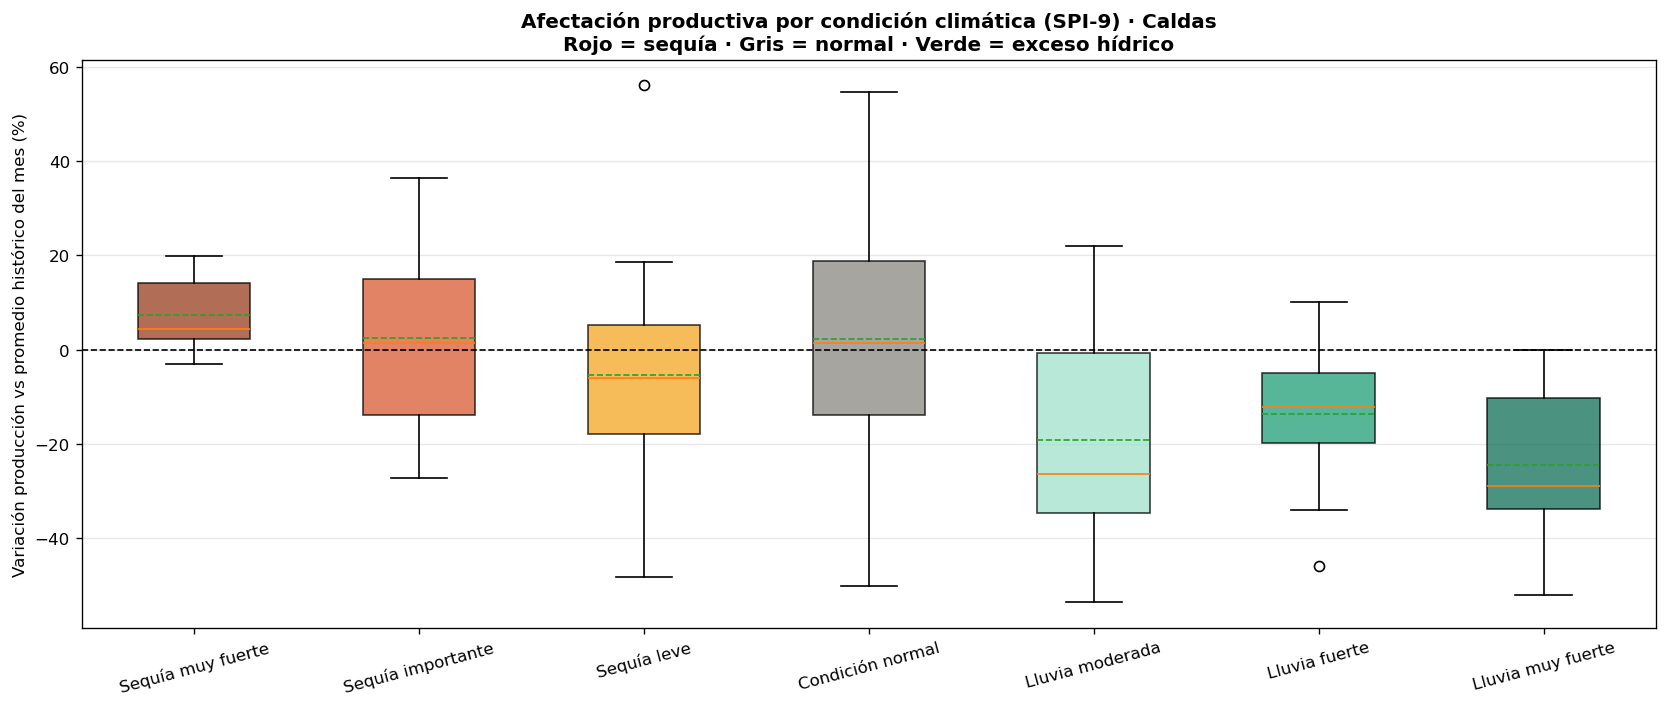

Gráfica guardada: vinc_H_afectacion_por_nivel.png


In [70]:
# --- H.1 Afectación productiva por nivel SPI-9 (ambas direcciones) ---
niveles_presentes = [n for n in orden_niveles if n in df_vinc['nivel_spi9'].cat.categories
                     and df_vinc[df_vinc['nivel_spi9'] == n].shape[0] > 0]

colores_mapa = {
    'Extremadamente seco':   '#993c1d',
    'Severamente seco':      '#d85a30',
    'Moderadamente seco':    '#f5a623',
    'Normal':                '#888780',
    'Moderadamente húmedo':  '#9FE1CB',
    'Muy húmedo':            '#1D9E75',
    'Extremadamente húmedo': '#0F6E56',
}

fig, ax = plt.subplots(figsize=(14, 6))
datos_box = [df_vinc[df_vinc['nivel_spi9'] == n]['variacion_obs_pct'].dropna()
             for n in niveles_presentes]

bp = ax.boxplot(datos_box, patch_artist=True,
                labels=[etiquetas[n] for n in niveles_presentes],
                showmeans=True, meanline=True)

for patch, nivel in zip(bp['boxes'], niveles_presentes):
    patch.set_facecolor(colores_mapa[nivel])
    patch.set_alpha(0.75)

ax.axhline(0, color='black', lw=1, linestyle='--')
ax.set_ylabel('Variación producción vs promedio histórico del mes (%)')
ax.set_title('Afectación productiva por condición climática (SPI-9) · Caldas\n'
             'Rojo = sequía · Gris = normal · Verde = exceso hídrico',
             fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('vinc_H_afectacion_por_nivel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: vinc_H_afectacion_por_nivel.png')

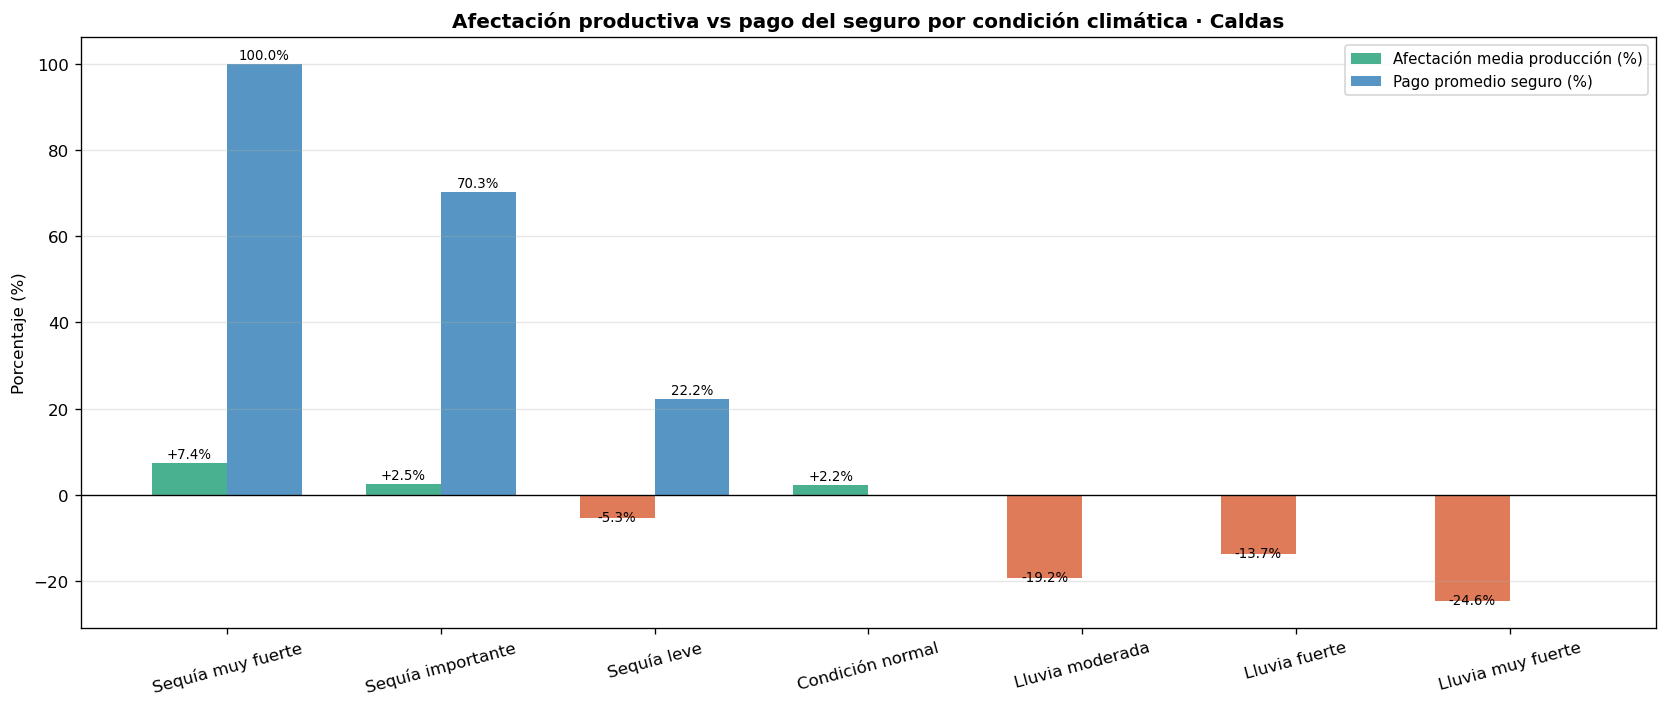

Gráfica guardada: vinc_H_afectacion_vs_pago.png


In [72]:
# --- H.2 Afectación media y pago por condición climática ---
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(niveles_presentes))
width = 0.35

afectaciones = [tabla.loc[n, 'afectacion_media_obs'] if n in tabla.index else 0
                for n in niveles_presentes]
pagos = [tabla.loc[n, 'pago_promedio_pct'] if n in tabla.index else 0
         for n in niveles_presentes]

# Barras de afectación con color según dirección
colores_bar = ['#d85a30' if v < 0 else '#1D9E75' for v in afectaciones]
bars1 = ax.bar(x - width/2, afectaciones, width,
               color=colores_bar, alpha=0.8,
               label='Afectación media producción (%)')
bars2 = ax.bar(x + width/2, pagos, width,
               color='#2c7bb6', alpha=0.8,
               label='Pago promedio seguro (%)')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([etiquetas[n] for n in niveles_presentes], rotation=15)
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Afectación productiva vs pago del seguro por condición climática · Caldas',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            h + (0.5 if h >= 0 else -1.5),
            f'{h:+.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('vinc_H_afectacion_vs_pago.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: vinc_H_afectacion_vs_pago.png')

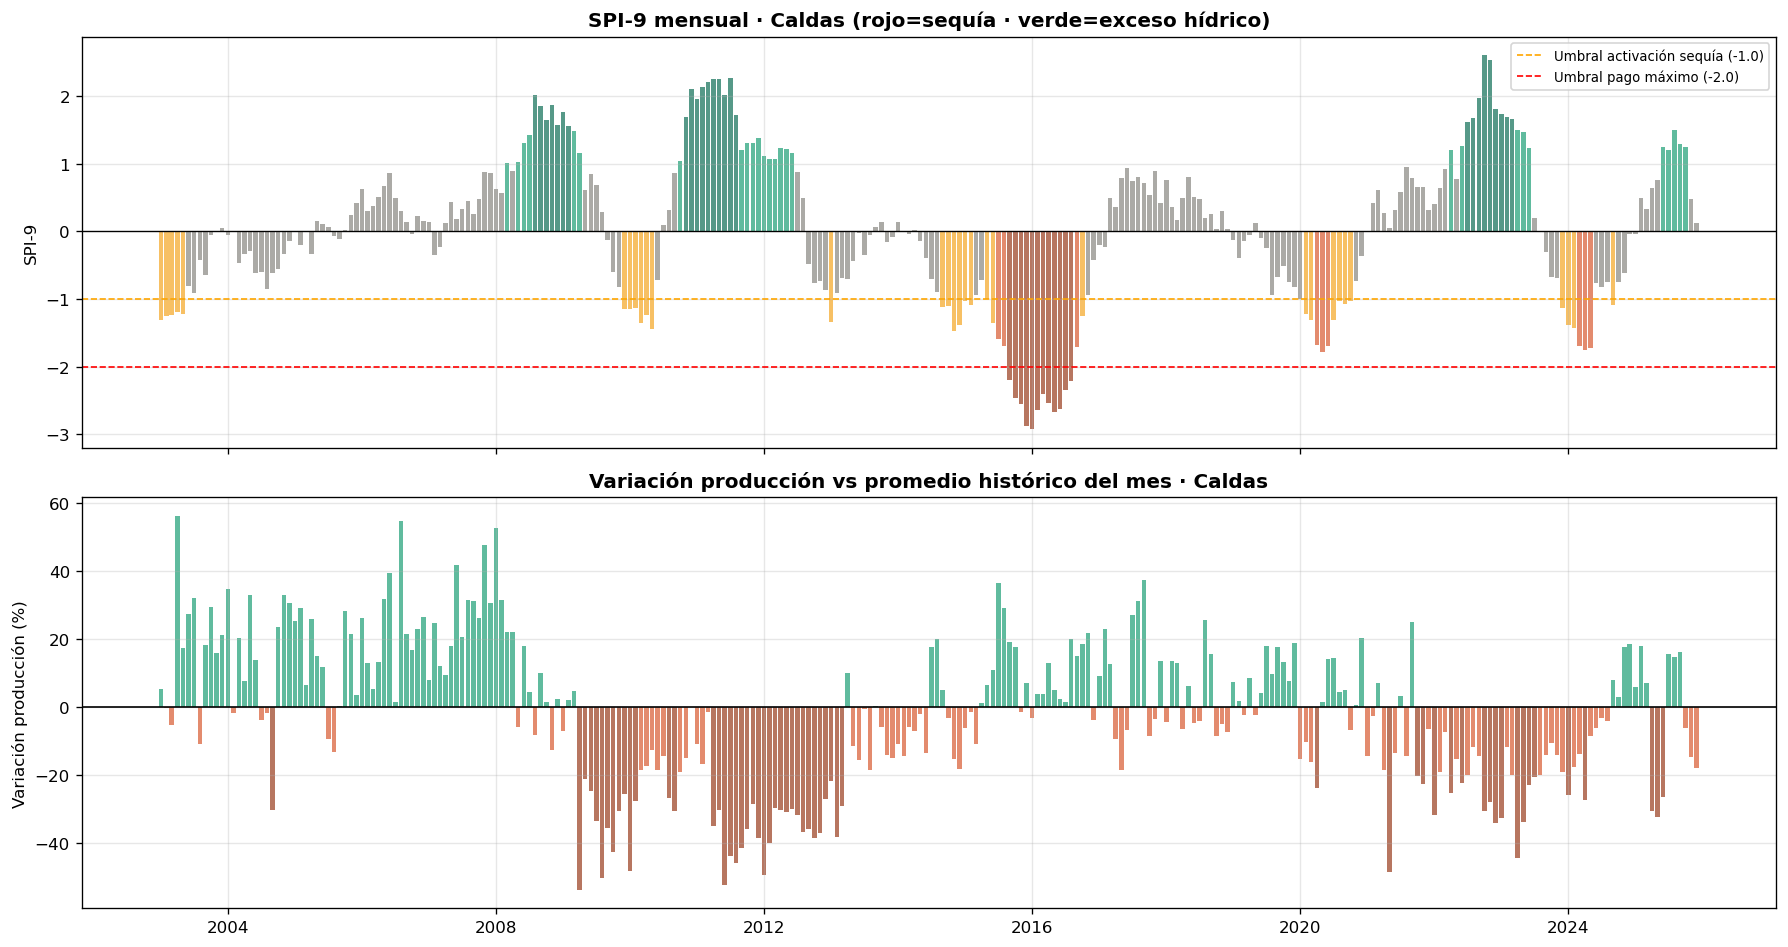

Gráfica guardada: vinc_H_serie_spi_produccion.png


In [74]:
# --- H.3 Serie temporal: SPI-9 y variación de producción ---
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# SPI-9 con color según dirección
axes[0].bar(df_vinc['fecha'], df_vinc['spi_9'],
            color=df_vinc['spi_9'].apply(
                lambda x: '#993c1d' if x <= -2.0
                else '#d85a30' if x <= -1.5
                else '#f5a623' if x <= -1.0
                else '#888780' if x <= 1.0
                else '#1D9E75' if x <= 1.5
                else '#0F6E56'
            ), alpha=0.7, width=25)
axes[0].axhline(-1.0, color='orange', lw=1, linestyle='--',
                label='Umbral activación sequía (-1.0)')
axes[0].axhline(-2.0, color='red',    lw=1, linestyle='--',
                label='Umbral pago máximo (-2.0)')
axes[0].axhline(0,    color='black',  lw=0.8)
axes[0].set_ylabel('SPI-9')
axes[0].set_title('SPI-9 mensual · Caldas (rojo=sequía · verde=exceso hídrico)',
                  fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Variación de producción
axes[1].bar(df_vinc['fecha'], df_vinc['variacion_obs_pct'],
            color=df_vinc['variacion_obs_pct'].apply(
                lambda x: '#993c1d' if x < -20
                else '#d85a30' if x < 0
                else '#1D9E75'
            ), alpha=0.7, width=25)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_ylabel('Variación producción (%)')
axes[1].set_title('Variación producción vs promedio histórico del mes · Caldas',
                  fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('vinc_H_serie_spi_produccion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: vinc_H_serie_spi_produccion.png')

In [76]:
# --- H.4 Exportar dataset vinculado completo ---
cols_export = ['fecha', 'month', TARGET, 'prod_estimada_rf',
               'prod_promedio_historico', 'variacion_obs_pct', 'variacion_est_pct',
               'spi_6', 'spi_9', 'pago_spi_6', 'pago_spi_9', 'nivel_spi9']

df_vinc[cols_export].to_csv('dataset_vinculado_spi_rf.csv', index=False)
print('Dataset vinculado exportado: dataset_vinculado_spi_rf.csv')
print(f'Columnas: {cols_export}')
print(f'Registros: {len(df_vinc)}')

Dataset vinculado exportado: dataset_vinculado_spi_rf.csv
Columnas: ['fecha', 'month', 'prod_caldas_miles_sacos', 'prod_estimada_rf', 'prod_promedio_historico', 'variacion_obs_pct', 'variacion_est_pct', 'spi_6', 'spi_9', 'pago_spi_6', 'pago_spi_9', 'nivel_spi9']
Registros: 276
